In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('../data/heart_disease_uci.csv')

In [3]:
df.head()

,ID,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [4]:
df['num'] = df['num'].apply(lambda x: 0 if x == 0 else 1)

In [5]:
df['num'].value_counts()

num
1    509
0    411
Name: count, dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ID        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   cp        920 non-null    object 
 4   trestbps  861 non-null    float64
 5   chol      890 non-null    float64
 6   fbs       830 non-null    object 
 7   restecg   918 non-null    object 
 8   thalch    865 non-null    float64
 9   exang     865 non-null    object 
 10  oldpeak   858 non-null    float64
 11  slope     611 non-null    object 
 12  ca        309 non-null    float64
 13  thal      434 non-null    object 
 14  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(7)
memory usage: 107.9+ KB


In [7]:
df.drop('ID', axis=1, inplace=True)

In [8]:
df.isnull().sum()

age           0
sex           0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [9]:
numerical_cols = [
    'age',
    'trestbps',
    'chol',
    'thalch',
    'oldpeak'
]

categorical_cols = [
    'sex',
    'cp',
    'fbs',
    'restecg',
    'exang',
    'slope',
    'ca',
    'thal'
]

In [10]:
from sklearn.impute import SimpleImputer

cat_imputer = SimpleImputer(strategy='most_frequent')

df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

df[categorical_cols] = df[categorical_cols].astype(str)

In [11]:
for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].unique())


sex
['Male' 'Female']

cp
['typical angina' 'asymptomatic' 'non-anginal' 'atypical angina']

fbs
['True' 'False']

restecg
['lv hypertrophy' 'normal' 'st-t abnormality']

exang
['False' 'True']

slope
['downsloping' 'flat' 'upsloping']

ca
['0.0' '3.0' '2.0' '1.0']

thal
['fixed defect' 'normal' 'reversable defect']


In [12]:
for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].unique())


sex
['Male' 'Female']

cp
['typical angina' 'asymptomatic' 'non-anginal' 'atypical angina']

fbs
['True' 'False']

restecg
['lv hypertrophy' 'normal' 'st-t abnormality']

exang
['False' 'True']

slope
['downsloping' 'flat' 'upsloping']

ca
['0.0' '3.0' '2.0' '1.0']

thal
['fixed defect' 'normal' 'reversable defect']


In [13]:
from sklearn.impute import SimpleImputer

In [14]:
num_imputer = SimpleImputer(strategy='median')

df[numerical_cols] = num_imputer.fit_transform(df[numerical_cols])

In [15]:
cat_imputer = SimpleImputer(strategy='most_frequent')

df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

In [16]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

In [17]:
for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].unique())


sex
['Male' 'Female']

cp
['typical angina' 'asymptomatic' 'non-anginal' 'atypical angina']

fbs
['True' 'False']

restecg
['lv hypertrophy' 'normal' 'st-t abnormality']

exang
['False' 'True']

slope
['downsloping' 'flat' 'upsloping']

ca
['0.0' '3.0' '2.0' '1.0']

thal
['fixed defect' 'normal' 'reversable defect']


In [18]:
X = df.drop('num', axis=1)
y = df['num']

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [22]:
preprocessor = ColumnTransformer([
    
    ('num', StandardScaler(), numerical_cols),
    
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

In [23]:
from sklearn.ensemble import RandomForestClassifier

In [24]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        random_state=42
    ))
])

In [25]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [26]:
y_pred = pipeline.predict(X_test)

In [27]:
from sklearn.metrics import accuracy_score, classification_report

In [28]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8478260869565217


In [29]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.77      0.82        82
           1       0.83      0.91      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.84      0.84       184
weighted avg       0.85      0.85      0.85       184



In [30]:
low_risk = pd.DataFrame([{
    'age': 35,
    'sex': 'Female',
    'cp': 'atypical angina',
    'trestbps': 110,
    'chol': 180,
    'fbs': 'False',
    'restecg': 'normal',
    'thalch': 180,
    'exang': 'False',
    'oldpeak': 0.2,
    'slope': 'upsloping',
    'ca': '0.0',
    'thal': 'normal'
}])

In [31]:
prediction = pipeline.predict(low_risk)

probability = pipeline.predict_proba(low_risk)

print("Prediction:", prediction[0])
print("Probability:", probability)

Prediction: 0
Probability: [[0.96353001 0.03646999]]


In [32]:
high_risk = pd.DataFrame([{
    'age': 63,
    'sex': 'Male',
    'cp': 'asymptomatic',
    'trestbps': 170,
    'chol': 320,
    'fbs': 'True',
    'restecg': 'lv hypertrophy',
    'thalch': 95,
    'exang': 'True',
    'oldpeak': 4.0,
    'slope': 'flat',
    'ca': '3.0',
    'thal': 'reversable defect'
}])

In [33]:
prediction = pipeline.predict(high_risk)

probability = pipeline.predict_proba(high_risk)

print("Prediction:", prediction[0])
print("Probability:", probability)

Prediction: 1
Probability: [[0.05189318 0.94810682]]


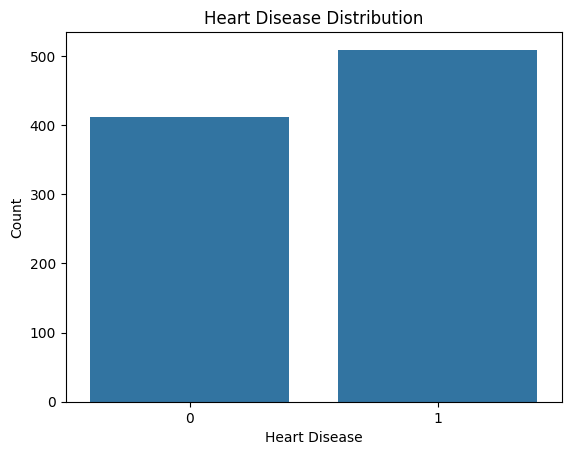

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='num', data=df)

plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Count")

plt.show()

This visualization shows the distribution of patients with and without heart disease in the dataset. The classes are relatively balanced, with slightly more patients having heart disease. Since the imbalance is not severe, the model can learn both classes effectively without heavy resampling techniques.

**Key Insight**
1. Class 1 (heart disease) slightly dominates
2. Dataset is reasonably balanced
3. No extreme imbalance problem

**Why is class balance important?**
*In classification problems, severe class imbalance can bias the model toward the majority class, leading to misleading accuracy. Since this dataset is fairly balanced, accuracy and recall become more reliable evaluation metrics.*

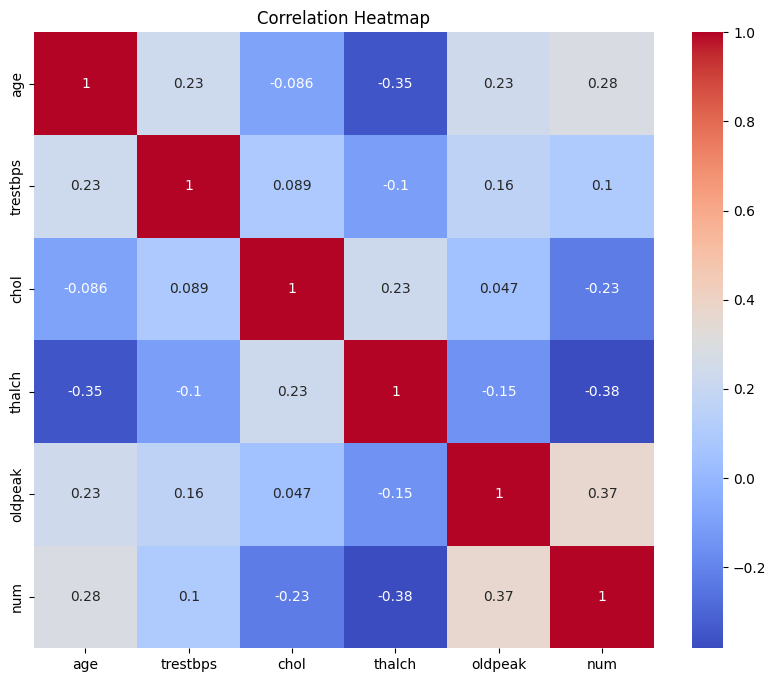

In [36]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df[numerical_cols + ['num']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

The correlation heatmap helps identify relationships between numerical features and the target variable. Features like oldpeak showed positive correlation with heart disease risk, while thalch (maximum heart rate achieved) showed a negative correlation. This helped validate that the selected features have predictive relevance.

**Key Insights**
1. Positive correlation with disease:
- oldpeak
- trestbps
2. Negative correlation:
- thalch

**Why use a heatmap?** *A heatmap provides a quick visual understanding of feature relationships and potential multicollinearity. It helps identify which variables may contribute more strongly to prediction.*

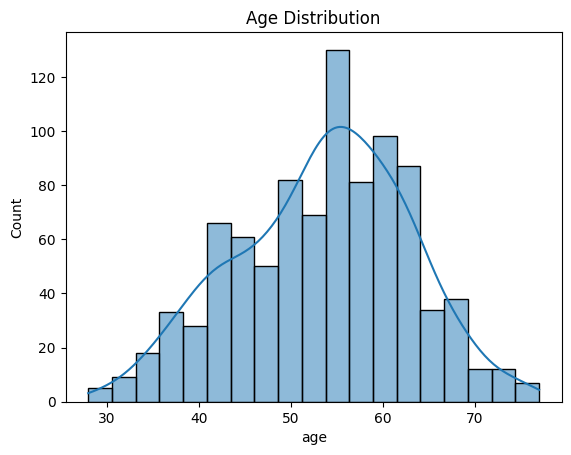

In [37]:
sns.histplot(df['age'], kde=True)

plt.title("Age Distribution")

plt.show()

This distribution shows that most patients fall within middle-aged and older age groups. Since cardiovascular diseases are more common with increasing age, the dataset aligns well with real-world medical trends.

Key Insight
1. Majority patients between 40–65
2. Supports realistic healthcare pattern

**Why include age in prediction?** *Age is a major cardiovascular risk factor because heart disease risk increases over time due to lifestyle, blood pressure, cholesterol accumulation, and reduced cardiac efficiency.*

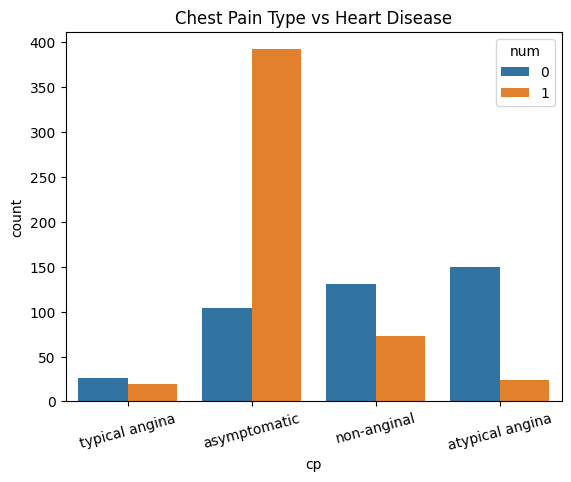

In [38]:
sns.countplot(x='cp', hue='num', data=df)

plt.title("Chest Pain Type vs Heart Disease")
plt.xticks(rotation=15)

plt.show()

This visualization compares chest pain categories with heart disease occurrence. Patients with asymptomatic chest pain showed higher disease presence, indicating that silent cardiovascular conditions can still carry significant risk.

IMPORTANT INSIGHT
- Asymptomatic chest pain: (VERY important medically)
patient may not show obvious pain, yet disease risk is high

**Why is chest pain important?** *Chest pain type is clinically significant because different pain patterns are associated with different cardiac conditions. The model learns these patterns to improve prediction accuracy.*

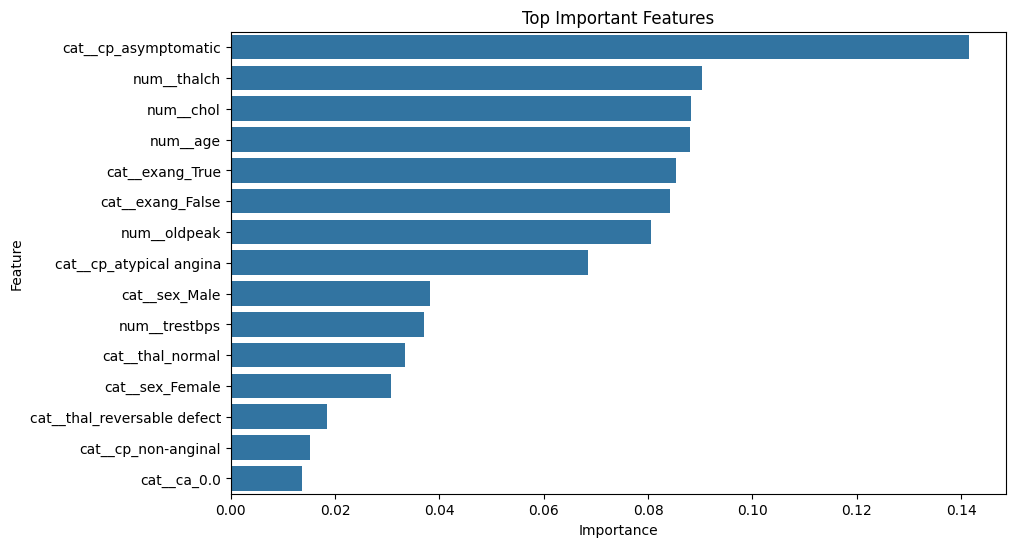

In [39]:
feature_names = pipeline.named_steps[
    'preprocessor'
].get_feature_names_out()

importances = pipeline.named_steps[
    'model'
].feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
).head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature'
)

plt.title("Top Important Features")

plt.show()

Feature importance analysis helped identify which variables contributed most to the model’s predictions. Features such as chest pain type, oldpeak, thal, and maximum heart rate showed strong predictive influence.

Key Insight
- cp
- oldpeak
- thalch
- ca
- thal

**Why analyze feature importance?** *Feature importance improves interpretability. In healthcare applications, understanding why the model predicts risk is important for transparency and trust.*

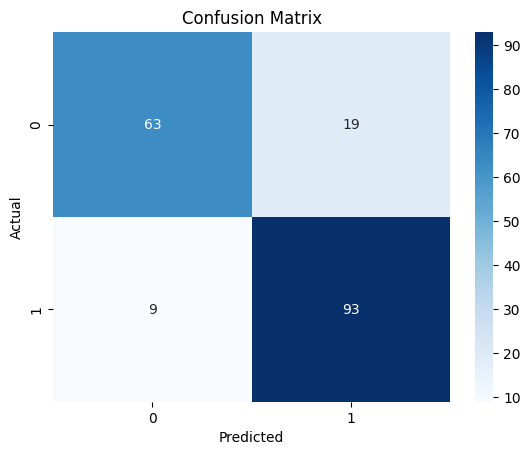

In [40]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

The confusion matrix helped evaluate how well the model classified positive and negative heart disease cases. It showed that the model correctly identified most patients while maintaining balanced false positives and false negatives.

**Which is more important in healthcare: precision or recall?**
*In healthcare prediction systems, recall is often more important because missing a high-risk patient can be dangerous. A false negative is usually costlier than a false positive.*

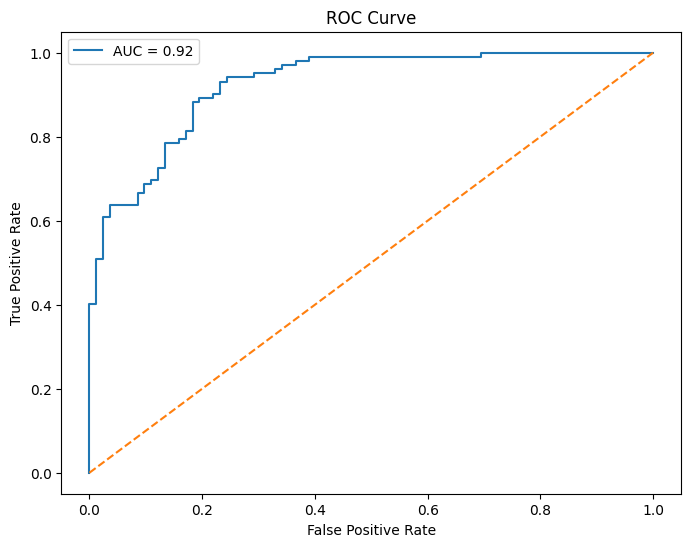

In [41]:
from sklearn.metrics import roc_curve, auc

y_probs = pipeline.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr,
         label=f'AUC = {roc_auc:.2f}')

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

The ROC curve evaluates the model’s ability to distinguish between positive and negative classes across different thresholds. The AUC score demonstrated that the model has strong discriminative capability.

**What does AUC mean?** *AUC measures how well the model separates classes. Higher AUC indicates better classification performance independent of a fixed threshold.*

In [34]:
import joblib
joblib.dump(pipeline, '../models/heartguard_pipeline.pkl')

['../models/heartguard_pipeline.pkl']

**Why Random Forest?** *I selected Random Forest because it handles both numerical and categorical features effectively, reduces overfitting through ensemble learning, and performs well on structured healthcare datasets.*

**Why use Pipeline and ColumnTransformer?** *The pipeline ensures preprocessing and prediction happen consistently during both training and inference. ColumnTransformer allowed separate handling of numerical scaling and categorical encoding in a clean and production-safe workflow.*